# Go2 EEG 解码演示 1：Logistic Regression 模型

本 Notebook 使用 `data/go2_eeg_preprocessed.npz` 作为输入，演示如何用基础的 multinomial Logistic Regression 完成 `L/S/R` 三分类解码。

数据已经在预处理阶段划分为训练集和测试集，因此这里仅在训练集内部做交叉验证和模型选择，最后在测试集上评估一次三分类准确率。

## 1. 导入依赖和读取路径

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "Source Han Sans SC"]:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
        break
plt.rcParams["axes.unicode_minus"] = False


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "go2_eeg_preprocessed.npz").exists():
            return candidate
    raise FileNotFoundError("无法找到 data/go2_eeg_preprocessed.npz")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "go2_eeg_preprocessed.npz"
# print(f"数据文件: {DATA_PATH}")

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, log_loss
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## 2. 读取预处理后的特征

Logistic Regression 使用二维特征矩阵，因此直接读取 `X_train_flat` 和 `X_test_flat`。`label_classes` 用于把整数标签还原成 `L/R/S`。

In [2]:
data = np.load(DATA_PATH, allow_pickle=True)

X_train = data["X_train_flat"].astype(np.float64)
X_test = data["X_test_flat"].astype(np.float64)
y_train = data["y_train"].astype(int)
y_test = data["y_test"].astype(int)
label_classes = data["label_classes"].astype(str)

print("数据形状")
print(f"- X_train: {X_train.shape}")
print(f"- X_test: {X_test.shape}")
print(f"- y_train: {y_train.shape}")
print(f"- y_test: {y_test.shape}")
print()
print("标签映射")
for idx, name in enumerate(label_classes):
    print(f"- {idx}: {name}")

print()
print("训练集标签数量")
for idx, count in zip(*np.unique(y_train, return_counts=True)):
    print(f"- {label_classes[idx]}: {count}")
print("测试集标签数量")
for idx, count in zip(*np.unique(y_test, return_counts=True)):
    print(f"- {label_classes[idx]}: {count}")


数据形状
- X_train: (141, 9984)
- X_test: (36, 9984)
- y_train: (141,)
- y_test: (36,)

标签映射
- 0: L
- 1: R
- 2: S

训练集标签数量
- L: 46
- R: 48
- S: 47
测试集标签数量
- L: 12
- R: 12
- S: 12


## 3. 建立 PCA + Logistic Regression pipeline

原始 flatten 特征维度为 9984，而训练样本只有 141 个。直接在高维空间训练线性模型容易过拟合，因此这里先用 PCA 压缩维度，再训练带 L2 正则的 multinomial Logistic Regression。

PCA 维度和正则强度只在训练集内部通过交叉验证选择。测试集不参与参数选择。

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(random_state=42)),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    random_state=42))])
参数搜索空间
- pca__n_components: [5, 10, 15, 20, 30, 40, 60, 80]
- logreg__C: [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]


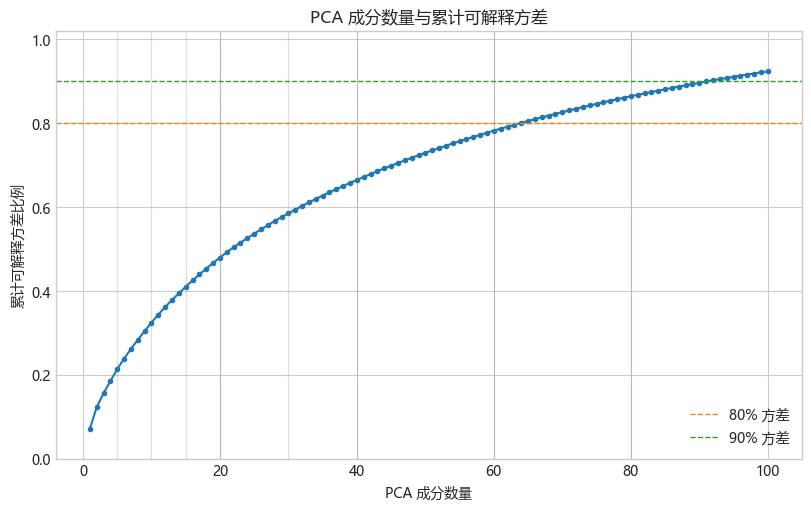

In [3]:
n_classes = len(label_classes)

model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(random_state=RANDOM_STATE)),
        (
            "logreg",
            LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {
    "pca__n_components": [5, 10, 15, 20, 30, 40, 60, 80],
    "logreg__C": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(model)
print("参数搜索空间")
for key, value in param_grid.items():
    print(f"- {key}: {value}")

# 只在训练集上查看 PCA 可解释方差，避免使用测试集信息。
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)
max_components_for_plot = min(100, X_train.shape[0] - 1, X_train.shape[1])
pca_for_plot = PCA(n_components=max_components_for_plot, random_state=RANDOM_STATE)
pca_for_plot.fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_for_plot.explained_variance_ratio_)
components = np.arange(1, max_components_for_plot + 1)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.plot(components, cumulative_variance, marker="o", markersize=3, lw=1.5)
for n_comp in param_grid["pca__n_components"]:
    if n_comp <= max_components_for_plot:
        ax.axvline(n_comp, color="tab:gray", alpha=0.25, lw=0.8)
ax.axhline(0.80, color="tab:orange", ls="--", lw=1, label="80% 方差")
ax.axhline(0.90, color="tab:green", ls="--", lw=1, label="90% 方差")
ax.set_title("PCA 成分数量与累计可解释方差")
ax.set_xlabel("PCA 成分数量")
ax.set_ylabel("累计可解释方差比例")
ax.set_ylim(0, 1.02)
ax.legend()
plt.show()

## 4. 训练集内交叉验证和参数选择

使用 Stratified K-Fold 保持每一折类别比例一致。网格搜索只在训练集上进行，用交叉验证准确率选择 PCA 维度和 Logistic Regression 的正则强度。

In [4]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    refit=True,
    n_jobs=None,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("最优参数")
for key, value in grid_search.best_params_.items():
    print(f"- {key}: {value}")
print(f"交叉验证最佳平均准确率: {grid_search.best_score_:.3f}")

cv_results = grid_search.cv_results_
rank_order = np.argsort(cv_results["rank_test_score"])[:8]
print()
print("前 8 组参数")
for idx in rank_order:
    params = cv_results["params"][idx]
    mean_acc = cv_results["mean_test_score"][idx]
    std_acc = cv_results["std_test_score"][idx]
    print(f"- acc={mean_acc:.3f} ± {std_acc:.3f}, params={params}")


最优参数
- logreg__C: 0.001
- pca__n_components: 10
交叉验证最佳平均准确率: 0.327

前 8 组参数
- acc=0.327 ± 0.071, params={'logreg__C': 0.03, 'pca__n_components': 10}
- acc=0.327 ± 0.074, params={'logreg__C': 0.001, 'pca__n_components': 10}
- acc=0.327 ± 0.071, params={'logreg__C': 0.3, 'pca__n_components': 10}
- acc=0.327 ± 0.071, params={'logreg__C': 0.1, 'pca__n_components': 10}
- acc=0.327 ± 0.071, params={'logreg__C': 1.0, 'pca__n_components': 10}
- acc=0.327 ± 0.071, params={'logreg__C': 10.0, 'pca__n_components': 10}
- acc=0.327 ± 0.071, params={'logreg__C': 3.0, 'pca__n_components': 10}
- acc=0.319 ± 0.076, params={'logreg__C': 0.003, 'pca__n_components': 10}


## 5. 参数搜索和最优参数学习情况

1. `C × PCA 成分数` 的交叉验证准确率热图，用于查看训练集内部参数搜索结果。
2. 在最优参数下的训练集规模学习曲线，用 log loss 展示训练/验证表现随训练样本数增加的变化。

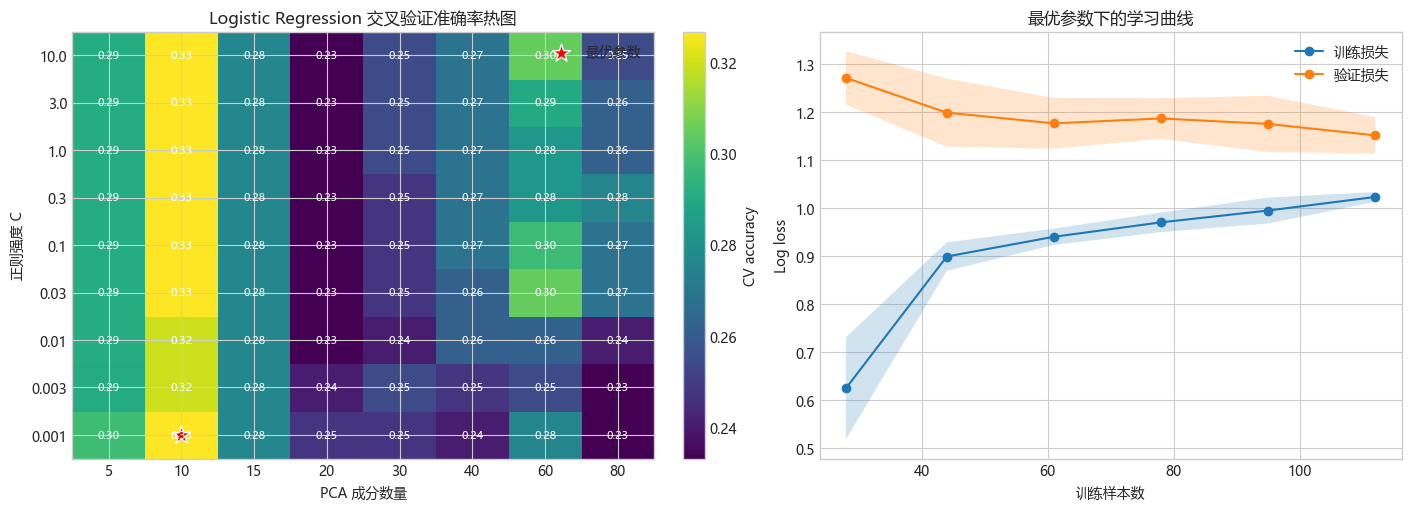

In [5]:
# 图 1：参数搜索热图。
cv_results = grid_search.cv_results_
pca_values = param_grid["pca__n_components"]
c_values = param_grid["logreg__C"]
heatmap = np.full((len(c_values), len(pca_values)), np.nan)

for params, mean_score in zip(cv_results["params"], cv_results["mean_test_score"]):
    row = c_values.index(params["logreg__C"])
    col = pca_values.index(params["pca__n_components"])
    heatmap[row, col] = mean_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
image = axes[0].imshow(heatmap, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Logistic Regression 交叉验证准确率热图")
axes[0].set_xlabel("PCA 成分数量")
axes[0].set_ylabel("正则强度 C")
axes[0].set_xticks(np.arange(len(pca_values)), pca_values)
axes[0].set_yticks(np.arange(len(c_values)), c_values)

best_pca = grid_search.best_params_["pca__n_components"]
best_c = grid_search.best_params_["logreg__C"]
best_col = pca_values.index(best_pca)
best_row = c_values.index(best_c)
axes[0].scatter(best_col, best_row, marker="*", s=180, color="red", edgecolor="white", label="最优参数")
axes[0].legend(loc="upper right")

for row in range(len(c_values)):
    for col in range(len(pca_values)):
        axes[0].text(col, row, f"{heatmap[row, col]:.2f}", ha="center", va="center", color="white", fontsize=8)
fig.colorbar(image, ax=axes[0], label="CV accuracy")

# 图 2：最优参数下的学习曲线。
train_sizes = np.linspace(0.25, 1.0, 6)
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="neg_log_loss",
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=None,
)

train_loss_curve = -train_scores
val_loss_curve = -val_scores
train_loss_mean = train_loss_curve.mean(axis=1)
train_loss_std = train_loss_curve.std(axis=1)
val_loss_mean = val_loss_curve.mean(axis=1)
val_loss_std = val_loss_curve.std(axis=1)

axes[1].plot(train_sizes_abs, train_loss_mean, marker="o", label="训练损失")
axes[1].fill_between(train_sizes_abs, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2)
axes[1].plot(train_sizes_abs, val_loss_mean, marker="o", label="验证损失")
axes[1].fill_between(train_sizes_abs, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)
axes[1].set_title("最优参数下的学习曲线")
axes[1].set_xlabel("训练样本数")
axes[1].set_ylabel("Log loss")
axes[1].legend()
plt.show()

## 6. 在完整训练集上训练最终模型

`GridSearchCV(refit=True)` 已经用最优参数在完整训练集上重新拟合了最终模型，因此这里直接读取最终训练集表现。

In [6]:
train_pred = best_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print(f"完整训练集准确率: {train_acc:.3f}")


完整训练集准确率: 0.461


## 7. 在测试集上解码并计算指标

测试集不参与交叉验证和模型选择，只在最后评估一次。

宏平均准确率: 0.5926
加权准确率: 0.5926
宏平均精确率: 0.3828
加权精确率: 0.3828
宏平均召回率: 0.3889
加权召回率: 0.3889
宏平均 F1: 0.3785
加权 F1: 0.3785

分类报告
              precision    recall  f1-score   support

           L       0.25      0.17      0.20        12
           R       0.55      0.50      0.52        12
           S       0.35      0.50      0.41        12

    accuracy                           0.39        36
   macro avg       0.38      0.39      0.38        36
weighted avg       0.38      0.39      0.38        36



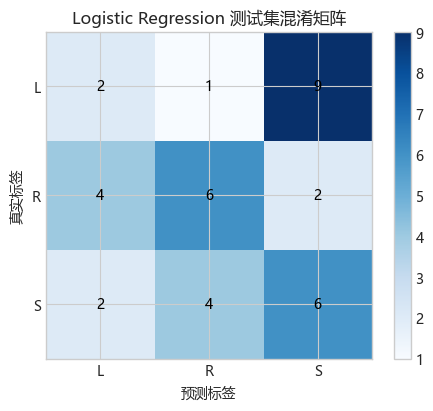

In [7]:
test_prob = best_model.predict_proba(X_test)
test_pred = np.argmax(test_prob, axis=1)

cm = confusion_matrix(y_test, test_pred, labels=np.arange(n_classes))
support = cm.sum(axis=1)
per_class_accuracy = []
for class_idx in range(n_classes):
    tp = cm[class_idx, class_idx]
    fp = cm[:, class_idx].sum() - tp
    fn = cm[class_idx, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    per_class_accuracy.append((tp + tn) / cm.sum())
per_class_accuracy = np.asarray(per_class_accuracy)

test_accuracy_macro = per_class_accuracy.mean()
test_accuracy_weighted = np.average(per_class_accuracy, weights=support)
test_precision_macro = precision_score(y_test, test_pred, average="macro", zero_division=0)
test_precision_weighted = precision_score(y_test, test_pred, average="weighted", zero_division=0)
test_recall_macro = recall_score(y_test, test_pred, average="macro", zero_division=0)
test_recall_weighted = recall_score(y_test, test_pred, average="weighted", zero_division=0)
test_f1_macro = f1_score(y_test, test_pred, average="macro", zero_division=0)
test_f1_weighted = f1_score(y_test, test_pred, average="weighted", zero_division=0)

print(f"宏平均准确率: {test_accuracy_macro:.4f}")
print(f"加权准确率: {test_accuracy_weighted:.4f}")
print(f"宏平均精确率: {test_precision_macro:.4f}")
print(f"加权精确率: {test_precision_weighted:.4f}")
print(f"宏平均召回率: {test_recall_macro:.4f}")
print(f"加权召回率: {test_recall_weighted:.4f}")
print(f"宏平均 F1: {test_f1_macro:.4f}")
print(f"加权 F1: {test_f1_weighted:.4f}")
print()
print("分类报告")
print(classification_report(y_test, test_pred, target_names=label_classes))

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Logistic Regression 测试集混淆矩阵")
ax.set_xlabel("预测标签")
ax.set_ylabel("真实标签")
ax.set_xticks(np.arange(n_classes), label_classes)
ax.set_yticks(np.arange(n_classes), label_classes)
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
plt.show()
